In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score
from sklearn.mixture import GaussianMixture

**Clustering**
---

The goal in this notebook is to find different strategies that the drivers have in different race track. First K-Means is implemented since it is the fundemental model in unsupervised learning and it can be used as an baseline to understand how well data works with clustering.

In [32]:
pd.set_option('display.max_columns', None)

In [33]:
clustering_data = pd.read_csv('/content/drive/MyDrive/DSA210/ML1.csv')
clustering_data.head(10)

,raceId,driverId,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,circuitId,stop_count,Track Length (km),Turns,Direction,Circuit Type
0,337,1,15.0,15,15,26.1,3,1,5.412,15,Clockwise,Race
1,337,3,16.0,16,16,26.1,3,1,5.412,15,Clockwise,Race
2,337,4,16.0,16,16,26.1,3,1,5.412,15,Clockwise,Race
3,337,5,30.0,30,30,26.1,3,1,5.412,15,Clockwise,Race
4,337,9,12.0,12,12,26.1,3,1,5.412,15,Clockwise,Race
5,337,13,17.0,17,17,26.1,3,1,5.412,15,Clockwise,Race
6,337,15,24.0,24,24,26.1,3,1,5.412,15,Clockwise,Race
7,337,16,15.0,15,15,26.1,3,1,5.412,15,Clockwise,Race
8,337,17,16.0,16,16,26.1,3,1,5.412,15,Clockwise,Race
9,337,18,16.0,16,16,26.1,3,1,5.412,15,Clockwise,Race


**Drop Columns**

These columns are dropped since K-Means can use these values to create an connection that is not related to the goal.

---

In [34]:
clustering_data.drop(columns=['raceId', 'circuitId', 'driverId'], inplace=True)
clustering_data.head(10)

,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction,Circuit Type
0,15.0,15,15,26.1,1,5.412,15,Clockwise,Race
1,16.0,16,16,26.1,1,5.412,15,Clockwise,Race
2,16.0,16,16,26.1,1,5.412,15,Clockwise,Race
3,30.0,30,30,26.1,1,5.412,15,Clockwise,Race
4,12.0,12,12,26.1,1,5.412,15,Clockwise,Race
5,17.0,17,17,26.1,1,5.412,15,Clockwise,Race
6,24.0,24,24,26.1,1,5.412,15,Clockwise,Race
7,15.0,15,15,26.1,1,5.412,15,Clockwise,Race
8,16.0,16,16,26.1,1,5.412,15,Clockwise,Race
9,16.0,16,16,26.1,1,5.412,15,Clockwise,Race


**Data Transformation**

Since K-means and other unsupervised algorithms use distance to create clusters the categorical variables are converted into numeric/boolean features.

Also, the values are standarized since there are major differences between the values of Track Length and temp. Therefore, the model can be more affected by columns that have larger values.

---

In [35]:
cluster_one_hot_encoded = pd.get_dummies(clustering_data, columns=['Direction', 'Circuit Type'])
cluster_one_hot_encoded.head(10)

,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street
0,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False
1,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False
2,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False
3,30.0,30,30,26.1,1,5.412,15,False,True,True,False,False
4,12.0,12,12,26.1,1,5.412,15,False,True,True,False,False
5,17.0,17,17,26.1,1,5.412,15,False,True,True,False,False
6,24.0,24,24,26.1,1,5.412,15,False,True,True,False,False
7,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False
8,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False
9,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False


In [36]:
scaler = preprocessing.StandardScaler()
clustering_s = scaler.fit_transform(cluster_one_hot_encoded)
clustering_standard_encoded = pd.DataFrame(clustering_s)
clustering_standard_encoded.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.950674,-0.158218,-1.395956,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
1,-0.854756,-0.063239,-1.320424,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
2,-0.854756,-0.063239,-1.320424,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
3,0.488097,1.266475,-0.262975,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
4,-1.238428,-0.443157,-1.622552,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
5,-0.758838,0.031741,-1.244892,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
6,-0.087411,0.696597,-0.716167,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
7,-0.950674,-0.158218,-1.395956,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
8,-0.854756,-0.063239,-1.320424,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442
9,-0.854756,-0.063239,-1.320424,1.225047,-1.005577,0.343144,-0.37117,-0.659429,0.659429,0.599352,-0.098938,-0.58442


**Silhouette and Elbow Graph**

These graphs are used for finding the ideal K value for the K-means.

In my case there isn't necessarily an good elbow value. On the other hand, using the silhouette value K = 5 can be selected and this value is also in the elbow part of the elbow graph as well.

---

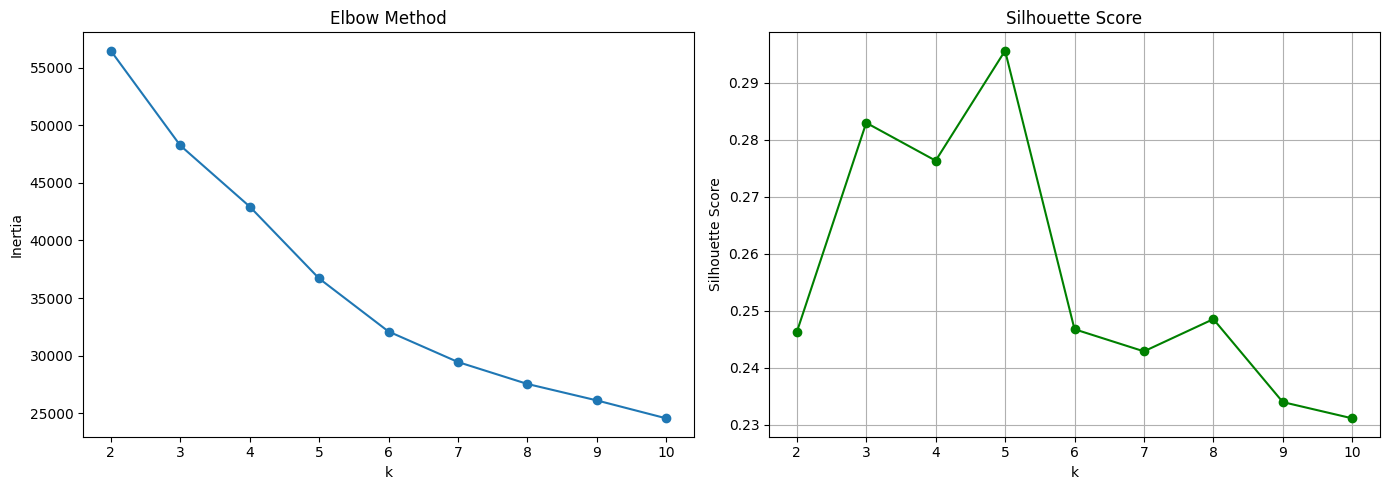

In [37]:
inertias = []
silhouettes = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(clustering_standard_encoded)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(clustering_standard_encoded, labels))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouettes, marker='o', color='green')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.grid(True)
plt.show()

**Check Clustering in 2D**

Using PCA the features can be reduced to 2 dimensions and this can be used for checking whether K-Means creates good clusters. From the graph it can be seen that three clusters overlap which is not the best outcome.

Since PCA reduces dimensions it may not generate the most accurate graph but the goal here is to understand the general clustering.

---

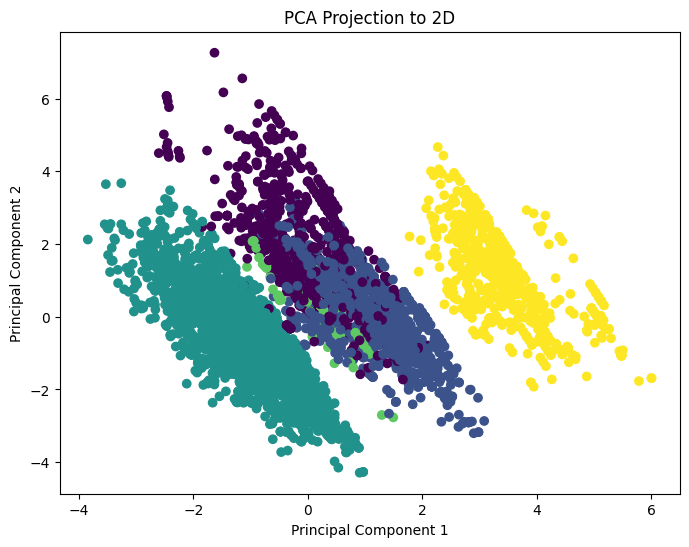

In [38]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(clustering_standard_encoded)

pca = PCA(n_components=2)
Clustering_PCA = pca.fit_transform(clustering_standard_encoded)
plt.figure(figsize=(8,6))
plt.scatter(Clustering_PCA[:, 0], Clustering_PCA[:, 1], c=labels, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection to 2D")
plt.show()

In [39]:
k_mean_result_df = cluster_one_hot_encoded.copy(deep=False)
k_mean_result_df['cluster'] = labels
k_mean_result_df.head(10)

,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street,cluster
0,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,2
1,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2
2,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2
3,30.0,30,30,26.1,1,5.412,15,False,True,True,False,False,2
4,12.0,12,12,26.1,1,5.412,15,False,True,True,False,False,2
5,17.0,17,17,26.1,1,5.412,15,False,True,True,False,False,2
6,24.0,24,24,26.1,1,5.412,15,False,True,True,False,False,2
7,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,2
8,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2
9,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2


In [40]:
res = k_mean_result_df.groupby('cluster').mean().reset_index()
res.head(6)

,cluster,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street
0,0,27.781288,19.523694,35.685298,17.522479,1.897934,4.277094,15.450790,0.0,1.0,0.0,0.0,1.0
1,1,24.467058,16.956679,33.384477,20.744946,1.954874,5.081307,16.853791,1.0,0.0,1.0,0.0,0.0
2,2,24.860938,15.770976,34.146053,19.443226,2.110628,5.278618,15.123990,0.0,1.0,1.0,0.0,0.0
3,3,26.850877,20.736842,32.807018,18.382456,1.543860,5.848000,18.000000,0.0,1.0,0.0,1.0,0.0
4,4,22.213650,16.626113,27.835312,25.095401,1.808605,5.538991,20.172107,1.0,0.0,0.0,0.0,1.0


**Result Analysis**

From the results it can be seen that the direction of the track and the circuit types are different in all of the clusters which means that model used these features primally to cluster. Also, the values of the other features are very close to each other which means that they may not be very effective in explaning the other clusters. Moreover, these results explain silhouette score it not necessarily high.

---

**Model 2**

The reason for low silhouette score could be due to clusters not having globular shapes therefore DBSCAN is used. In DBSCAN there are two hyperparameters to estimate minpts and eps.

According to the Pratik Nabiya (2020), if the domain information isn't known then use minPts = 2 * D where D represents the number of features/dimensions. From this I created the range [D, (2 * D) + 4] to see how the model changes and checked whether it overfit or not.

Furthermore according to the luisfelipe18 (2021) the Nearest Neighbors method can be used to plot the elbow graph.  

In the elbow graph I selected the same value for the elbow value which is 5500.

Reference list can be found at the end of the notebook.

---

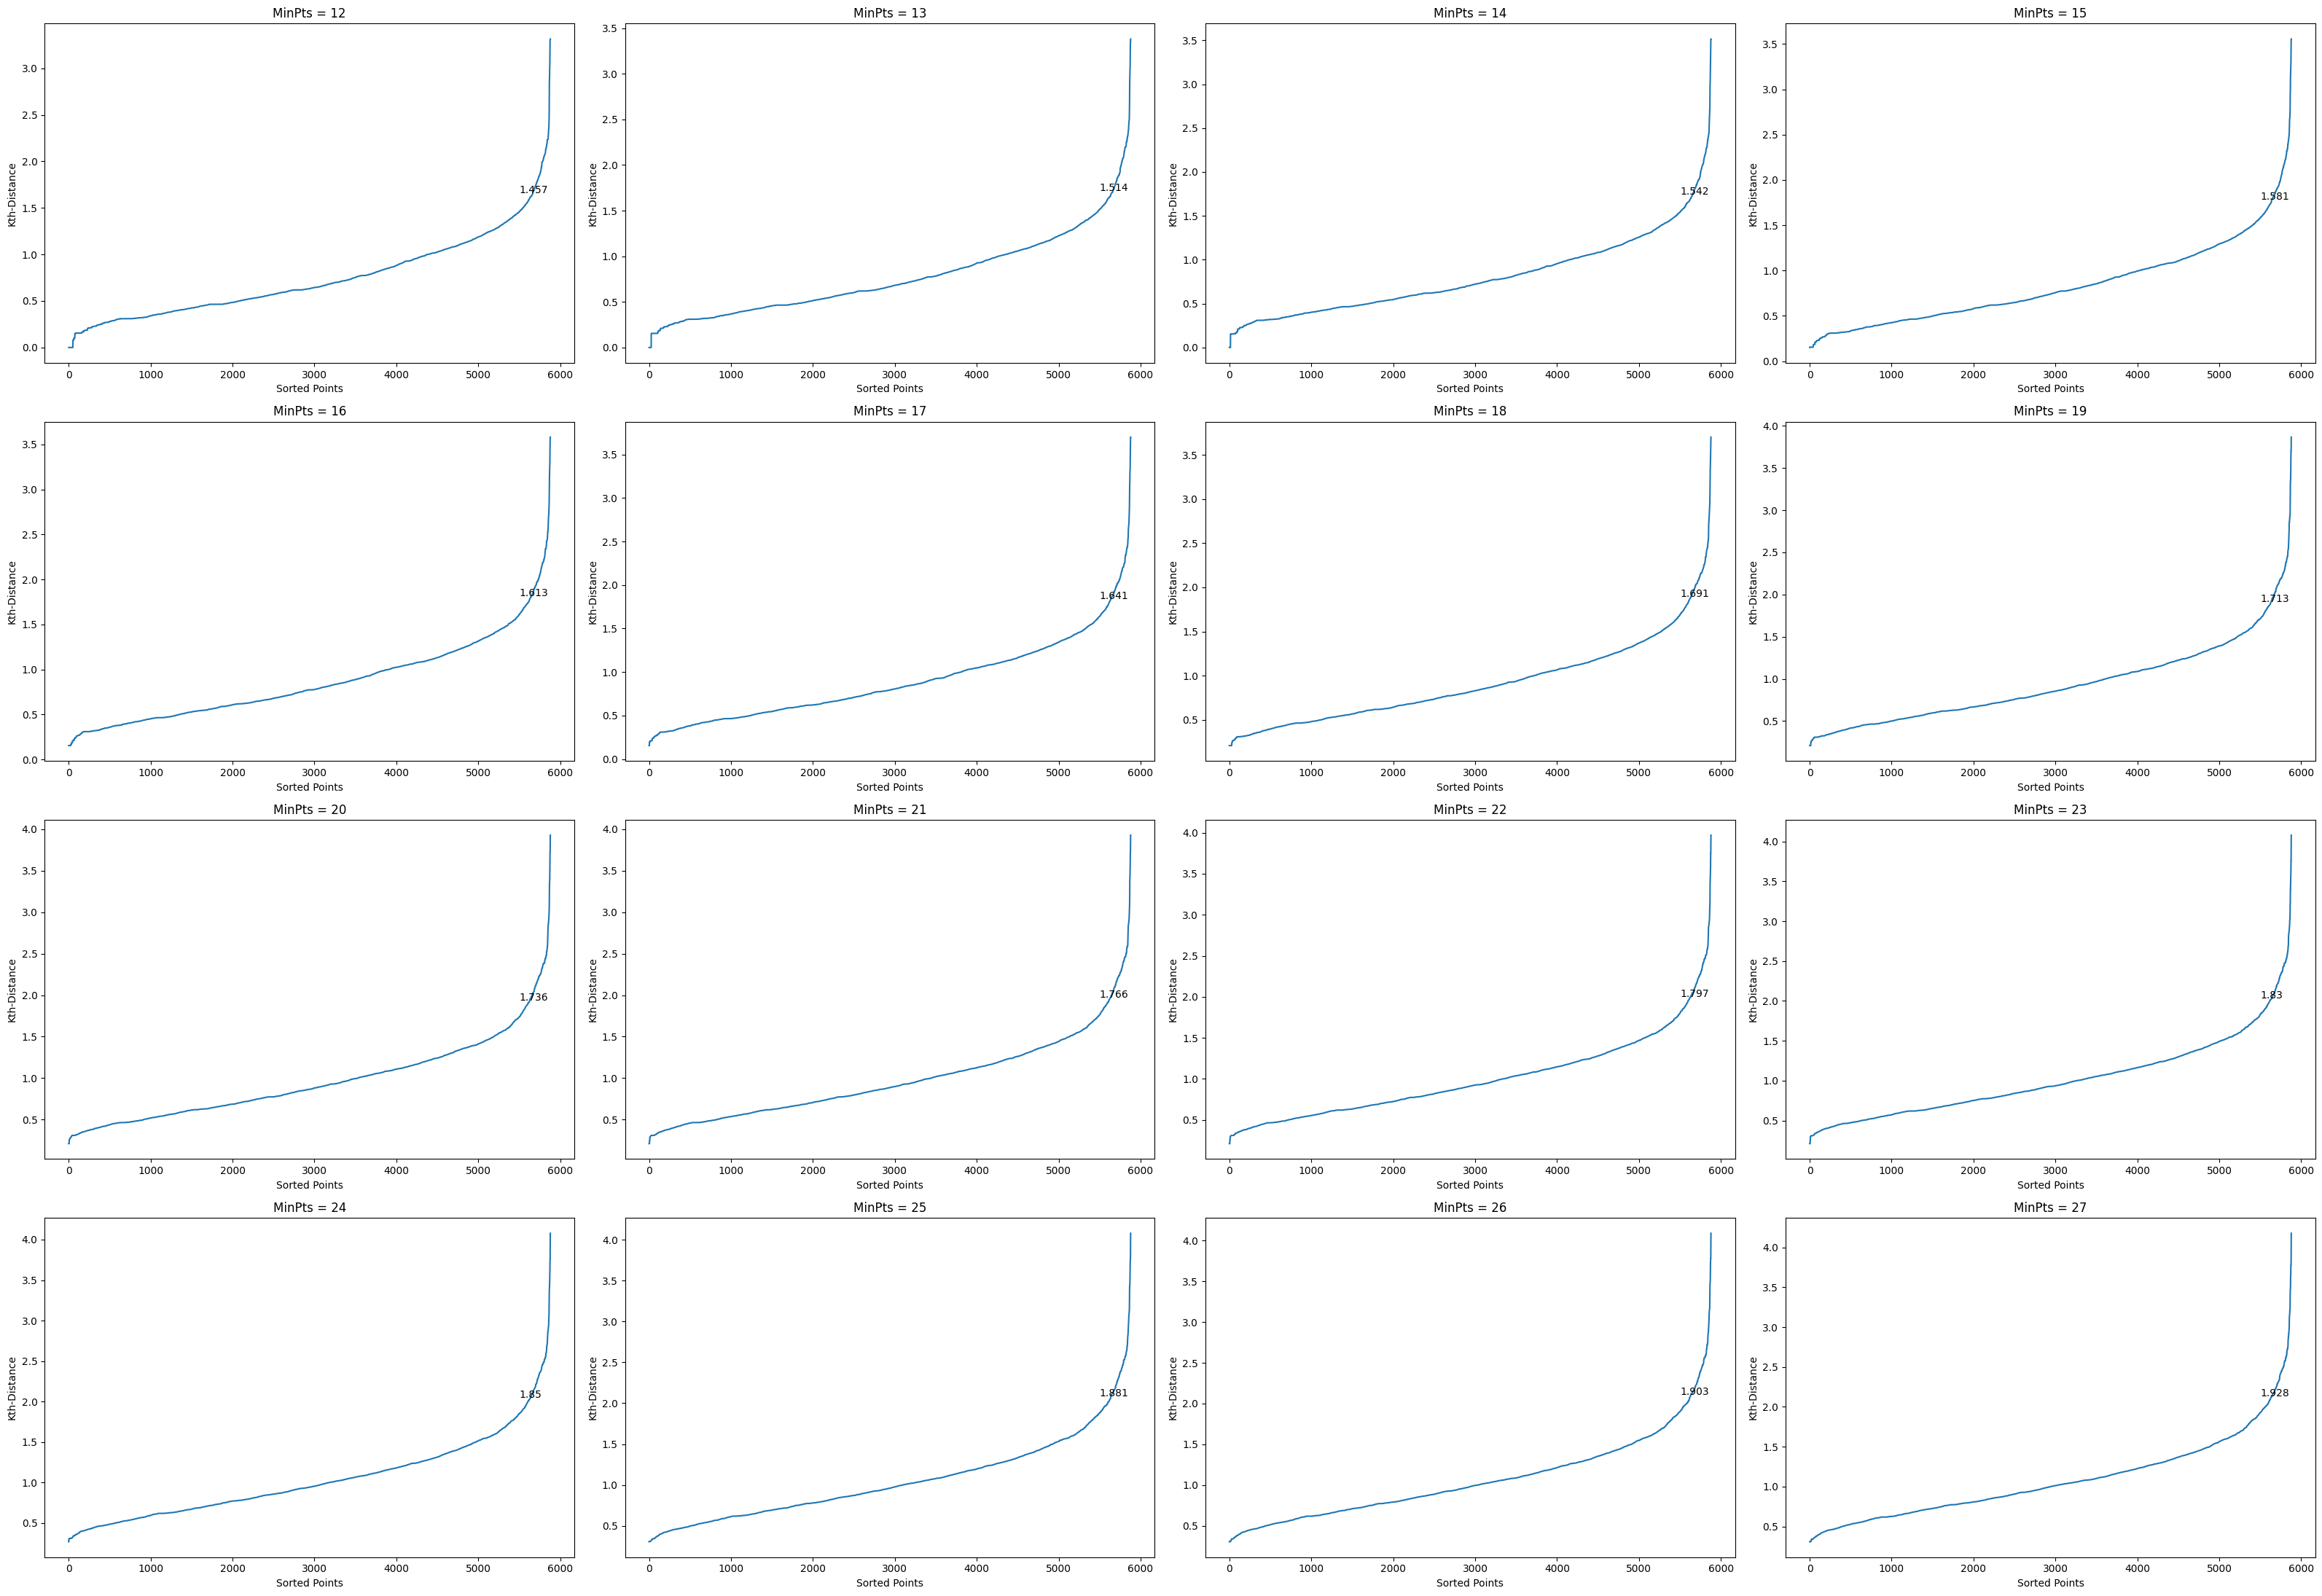

In [41]:
dimension = 12
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(32,22))
row = 0
col = 0
idx = 5500
eps_pts_tuple = []
for i in range(dimension, (2*dimension) + 4):
  nbrs = NearestNeighbors(n_neighbors=i, algorithm='auto').fit(clustering_standard_encoded)
  distances, indices = nbrs.kneighbors(clustering_standard_encoded)
  kth_distance_sorted = np.sort(distances[:, i-1])
  eps = kth_distance_sorted[idx]
  temp = (round(eps, 4), i)
  eps_pts_tuple.append(temp)

  ax[row, col].plot(kth_distance_sorted)
  ax[row, col].set_xlabel("Sorted Points")
  ax[row, col].set_ylabel("Kth-Distance")
  ax[row, col].set_title(f'MinPts = {i}')
  ax[row, col].annotate(round(eps, 3), xy=(idx, eps + 0.2))

  if(col == 3):
    row += 1
    col = 0
  else:
    col += 1

plt.tight_layout()
plt.show()


In [42]:
print(eps_pts_tuple)

[(np.float64(1.4571), 12), (np.float64(1.5142), 13), (np.float64(1.5418), 14), (np.float64(1.5815), 15), (np.float64(1.6127), 16), (np.float64(1.6413), 17), (np.float64(1.6914), 18), (np.float64(1.7126), 19), (np.float64(1.7358), 20), (np.float64(1.7657), 21), (np.float64(1.7968), 22), (np.float64(1.8298), 23), (np.float64(1.85), 24), (np.float64(1.8809), 25), (np.float64(1.9027), 26), (np.float64(1.928), 27)]


**Results**

For each minpts - eps value different clusters are created and it can be seen that when number of points is equal to 17 it creates the best model by looking at the silhouette score. After that the model may be overfitting since the silhouette scores do not change.

---

In [43]:
for eps, minpts in eps_pts_tuple:
  dbscan_cluster = DBSCAN(eps=eps, min_samples=minpts)
  dbscan_labels = dbscan_cluster.fit_predict(clustering_standard_encoded)

  n_clusters = len(set(dbscan_labels))

  score = silhouette_score(clustering_standard_encoded, dbscan_labels)
  print(f"Distance={eps}, Min number of Points={minpts}, Number of clusters= {n_clusters}, Silhouette Score: {round(score, 3)}")


Distance=1.4571, Min number of Points=12, Number of clusters= 13, Silhouette Score: 0.216
Distance=1.5142, Min number of Points=13, Number of clusters= 12, Silhouette Score: 0.218
Distance=1.5418, Min number of Points=14, Number of clusters= 12, Silhouette Score: 0.219
Distance=1.5815, Min number of Points=15, Number of clusters= 11, Silhouette Score: 0.22
Distance=1.6127, Min number of Points=16, Number of clusters= 10, Silhouette Score: 0.227
Distance=1.6413, Min number of Points=17, Number of clusters= 9, Silhouette Score: 0.277
Distance=1.6914, Min number of Points=18, Number of clusters= 8, Silhouette Score: 0.276
Distance=1.7126, Min number of Points=19, Number of clusters= 8, Silhouette Score: 0.276
Distance=1.7358, Min number of Points=20, Number of clusters= 8, Silhouette Score: 0.275
Distance=1.7657, Min number of Points=21, Number of clusters= 8, Silhouette Score: 0.275
Distance=1.7968, Min number of Points=22, Number of clusters= 8, Silhouette Score: 0.275
Distance=1.8298, 

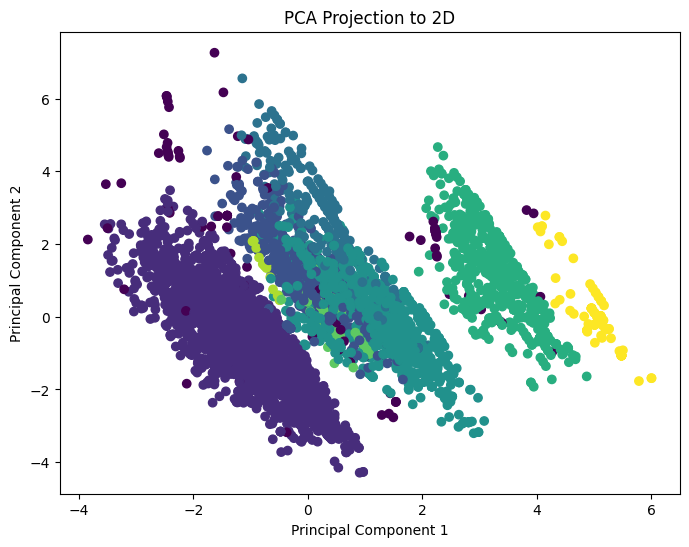

In [44]:
eps = 1.6413
pts = 17
dbscan_cluster = DBSCAN(eps=eps, min_samples=pts)
dbscan_labels = dbscan_cluster.fit_predict(clustering_standard_encoded)

pca = PCA(n_components=2)
Clustering_PCA_db = pca.fit_transform(clustering_standard_encoded)
plt.figure(figsize=(8,6))
plt.scatter(Clustering_PCA_db[:, 0], Clustering_PCA_db[:, 1], c=dbscan_labels, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection to 2D")
plt.show()

**Graph Analysis**

From the PCA 2D graph it can be seen that there are still many overlaps between the clusters. Therefore another model that allows overlaps can be used.

---

In [45]:
DBSCAN_result_df = cluster_one_hot_encoded.copy(deep=False)
DBSCAN_result_df['cluster'] = dbscan_labels
DBSCAN_result_df.head(10)

,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street,cluster
0,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,0
1,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,0
2,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,0
3,30.0,30,30,26.1,1,5.412,15,False,True,True,False,False,0
4,12.0,12,12,26.1,1,5.412,15,False,True,True,False,False,0
5,17.0,17,17,26.1,1,5.412,15,False,True,True,False,False,0
6,24.0,24,24,26.1,1,5.412,15,False,True,True,False,False,0
7,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,0
8,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,0
9,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,0


In [46]:
res_dbscan = DBSCAN_result_df.groupby('cluster').mean().reset_index()
res_dbscan.head(7)

,cluster,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street
0,-1,38.820000,13.960000,47.510000,18.533000,3.860000,5.115330,16.790000,0.45,0.55,0.26,0.06,0.68
1,0,24.814977,15.758814,34.068643,19.448924,2.101716,5.279365,15.126677,0.00,1.00,1.00,0.00,0.00
2,1,24.571285,17.098394,33.813253,17.154618,1.925703,4.802928,13.481928,0.00,1.00,0.00,0.00,1.00
3,2,29.377163,23.529412,35.425606,18.362976,1.574394,3.337000,19.000000,0.00,1.00,0.00,0.00,1.00
4,3,24.524201,17.042009,33.486758,20.864566,1.940639,5.080842,16.850228,1.00,0.00,1.00,0.00,0.00
5,4,22.810127,17.376130,28.815552,24.844846,1.752260,5.432081,19.066908,1.00,0.00,0.00,0.00,1.00
6,5,24.097222,21.611111,26.583333,19.611111,1.250000,5.848000,18.000000,0.00,1.00,0.00,1.00,0.00


**Model 3**

In this part Gaussian Mixture Model (GMM) is used since it assigns possibilities of being in an cluster rather than assiging one cluster to each node. Therefore it may create better results since the clusters overlap.

---

**Evaluation Method**

According to dontloo (2017) BIC can be used for selecting the number of clusters.

[Reference list can be found here](#scrollTo=a7uvJwVfLECW&line=1&uniqifier=1)

---

In [47]:
k_values = range(2, 10)
bic_values = []
for k in k_values:
    GMM = GaussianMixture(n_components=k, random_state=42, n_init=10)
    GMM_labels = GMM.fit_predict(clustering_standard_encoded)
    bic = GMM.bic(clustering_standard_encoded)
    print(f"BIC Score for k = {k} is: {bic}")
    bic_values.append(bic)


BIC Score for k = 2 is: -137980.94830022723
BIC Score for k = 3 is: -207954.74687542056
BIC Score for k = 4 is: -225581.35579813653
BIC Score for k = 5 is: -251845.54700377386
BIC Score for k = 6 is: -277287.17968079913
BIC Score for k = 7 is: -289391.4387306153
BIC Score for k = 8 is: -295859.2867371451
BIC Score for k = 9 is: -326352.7518033168


**Evaluation**

From the BIC values it can be seen that there is not an significant change after k = 3 therefore it is selected.

---

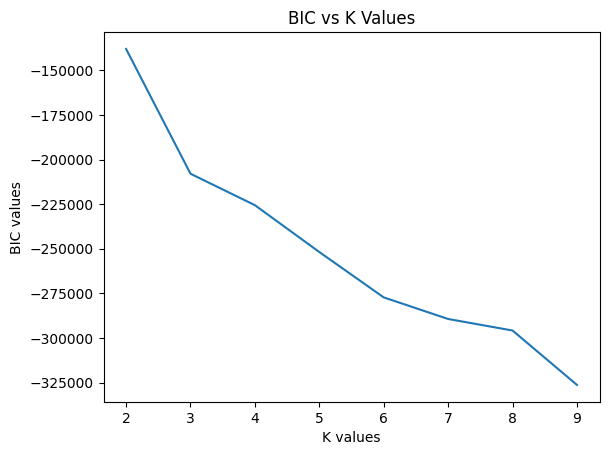

In [48]:
plt.plot(k_values, bic_values)
plt.xlabel('K values')
plt.ylabel('BIC values')
plt.title("BIC vs K Values")
plt.show()

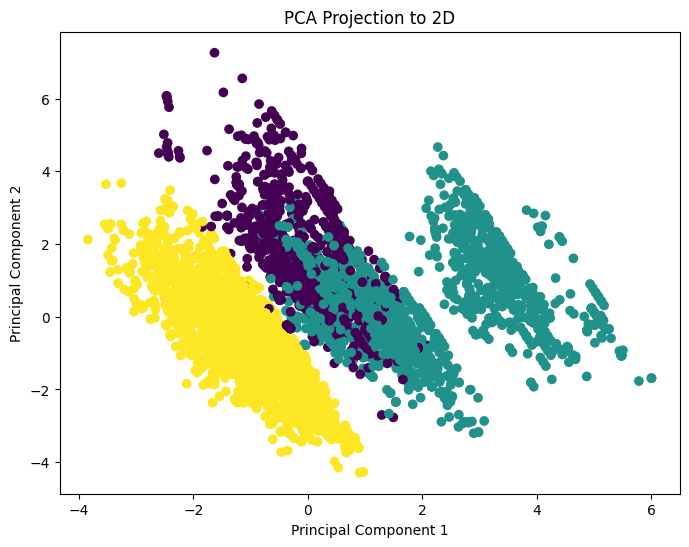

In [49]:
GMM = GaussianMixture(n_components=3, random_state=42, n_init=10)
GMM_labels = GMM.fit_predict(clustering_standard_encoded)

pca = PCA(n_components=2)
Clustering_PCA_db = pca.fit_transform(clustering_standard_encoded)
plt.figure(figsize=(8,6))
plt.scatter(Clustering_PCA_db[:, 0], Clustering_PCA_db[:, 1], c=GMM_labels, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection to 2D")
plt.show()

In [50]:
score = silhouette_score(clustering_standard_encoded, GMM_labels)
print(f"Silhouette Score for GMM: {round(score, 3)}")

Silhouette Score for GMM: 0.283


In [51]:
GMM_result_df = cluster_one_hot_encoded.copy(deep=False)
GMM_result_df['cluster'] = GMM_labels
GMM_result_df.head(10)

,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street,cluster
0,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,2
1,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2
2,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2
3,30.0,30,30,26.1,1,5.412,15,False,True,True,False,False,2
4,12.0,12,12,26.1,1,5.412,15,False,True,True,False,False,2
5,17.0,17,17,26.1,1,5.412,15,False,True,True,False,False,2
6,24.0,24,24,26.1,1,5.412,15,False,True,True,False,False,2
7,15.0,15,15,26.1,1,5.412,15,False,True,True,False,False,2
8,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2
9,16.0,16,16,26.1,1,5.412,15,False,True,True,False,False,2


In [52]:
res_gmm = GMM_result_df.groupby('cluster').mean().reset_index()
res_gmm.head(3)

,cluster,stop_lap_median,firstPitStopLap,lastPitStopLap,temp,stop_count,Track Length (km),Turns,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street
0,0,27.721023,19.602273,35.498864,17.578182,1.875000,4.378845,15.615909,0.0,1.0,0.000000,0.064773,0.935227
1,1,23.614759,16.831650,31.285634,22.390404,1.899551,5.254415,18.108866,1.0,0.0,0.621773,0.000000,0.378227
2,2,24.860938,15.770976,34.146053,19.443226,2.110628,5.278618,15.123990,0.0,1.0,1.000000,0.000000,0.000000


**Reference List**


1.   dontloo. (2017, December 7). *Just some extension to Dikran Marsupial's comment (cross-validation).* [Comment on the online forum post *Optimal number of components in a Gaussian mixture*]. Cross Validated. https://stats.stackexchange.com/a/317549

2. Pratik Nabriya. (2020, July 23). *minPts is selected based on the domain knowledge.* [Comment on the online forum post *A routine to choose eps and minPts for DBSCAN*]. Cross Validated. https://stats.stackexchange.com/a/478681

3. luisfelipe18. (2021, August 25). *Maybe a bit late, but I would like to add an answer here for future knowledge.* [Comment on the online forum post *A routine to choose eps and minPts for DBSCAN*]. Cross Validated. https://stats.stackexchange.com/a/541340

